# NOTEBOOK V4 - ENTRENAMIENTO CON 10.000 IMÁGENES (GT RUIDOSO)

## Objetivo
Entrenar un Faster R-CNN con 10.000 imágenes seleccionadas por muestreo estratificado.
Mismo GT ruidoso del índice INBNV (sin limpieza manual).

## Propósito en la tesis
Comparar con V3 (600 imgs, GT ruidoso) y V5 (615 imgs, GT limpio)
para demostrar: **¿qué importa más, cantidad de datos o calidad de etiquetas?**

## Tiempo estimado
~3 días en CPU (10.000 imgs × 5 épocas × ~6s/img)

## PASO 1: Generación del Dataset V4 (10.000 imágenes, muestreo estratificado)

In [1]:
import os
import re
import shutil
import random
from collections import defaultdict
from tqdm import tqdm

# --- CONFIGURACIÓN ---
SOURCE_IMG_DIR = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles"
SOURCE_SHP_DIR = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
OUTPUT_DIR = r"D:\Silos\Dataset_V4_10k"
SAMPLE_SIZE = 10000
SEED = 456  # Seed diferente a V3 y Golden para no pisar selecciones

YEARS_TO_INCLUDE = [2020, 2021, 2022, 2023, 2024,2025]  # SIN 2026 -> reservado para test
MONTHS_TO_INCLUDE = [4, 5, 6, 7, 8]
MIN_TILE_DISTANCE = 0
TRAIN_RATIO = 0.85  # 85% train, 15% val


def parse_tile_name(filename):
    m = re.match(r'(\d{4})_(\d{1,2})_\d{1,2}_\d+_tile_r(\d+)_c(\d+)', filename)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3)), int(m.group(4))
    return None


def stratified_sample(all_tifs, sample_size, seed, years, months, min_dist):
    random.seed(seed)
    
    parsed = []
    for f in all_tifs:
        info = parse_tile_name(f)
        if info is None:
            continue
        year, month, row, col = info
        if year not in years or month not in months:
            continue
        parsed.append({'filename': f, 'year': year, 'month': month, 'row': row, 'col': col})
    
    print(f"Tiles válidos (años {years}, meses {months}): {len(parsed)}")
    
    groups = defaultdict(list)
    for item in parsed:
        key = (item['year'], item['month'])
        groups[key].append(item)
    
    print(f"Estratos año-mes encontrados: {len(groups)}")
    for k, v in sorted(groups.items()):
        print(f"  {k[0]}-{k[1]:02d}: {len(v)} tiles disponibles")
    
    total_available = sum(len(v) for v in groups.values())
    per_stratum = {}
    remainder = sample_size
    
    for key in sorted(groups.keys()):
        n_available = len(groups[key])
        ideal = max(1, int(sample_size * n_available / total_available))
        per_stratum[key] = min(ideal, n_available)
        remainder -= per_stratum[key]
    
    if remainder > 0:
        for key in sorted(groups.keys(), key=lambda k: len(groups[k]), reverse=True):
            can_add = len(groups[key]) - per_stratum[key]
            add = min(can_add, remainder)
            per_stratum[key] += add
            remainder -= add
            if remainder <= 0:
                break
    
    print(f"\nPlan de muestreo (target {sample_size}):")
    for k in sorted(per_stratum.keys()):
        print(f"  {k[0]}-{k[1]:02d}: {per_stratum[k]} de {len(groups[k])} disponibles")
    
    selected = []
    occupied_positions = set()
    
    for key in sorted(groups.keys()):
        candidates = groups[key].copy()
        random.shuffle(candidates)
        
        n_target = per_stratum[key]
        stratum_selected = []
        
        for item in candidates:
            if len(stratum_selected) >= n_target:
                break
            
            r, c = item['row'], item['col']
            too_close = False
            for (oy, om, orow, ocol) in occupied_positions:
                if oy == item['year'] and om == item['month']:
                    if abs(r - orow) < min_dist and abs(c - ocol) < min_dist:
                        too_close = True
                        break
            
            if not too_close:
                stratum_selected.append(item)
                occupied_positions.add((item['year'], item['month'], r, c))
        
        selected.extend(stratum_selected)
    
    print(f"\nTotal seleccionado tras filtro espacial: {len(selected)}")
    return selected


def crear_dataset_v4():
    print("--- CREANDO DATASET V4 (10k ESTRATIFICADO) ---")
    
    all_tifs = sorted([f for f in os.listdir(SOURCE_IMG_DIR) if f.lower().endswith('.tif')])
    print(f"Total de tiles en disco: {len(all_tifs)}")
    
    selected_items = stratified_sample(
        all_tifs, SAMPLE_SIZE, SEED,
        years=YEARS_TO_INCLUDE,
        months=MONTHS_TO_INCLUDE,
        min_dist=MIN_TILE_DISTANCE
    )
    
    # Shuffle y split train/val
    random.seed(SEED)
    random.shuffle(selected_items)
    split_idx = int(len(selected_items) * TRAIN_RATIO)
    splits = {
        'train': selected_items[:split_idx],
        'val': selected_items[split_idx:]
    }
    
    print(f"\nSplit: train={len(splits['train'])}, val={len(splits['val'])}")
    
    # Limpiar carpeta destino
    if os.path.exists(OUTPUT_DIR):
        print(f"Limpiando carpeta anterior: {OUTPUT_DIR}")
        shutil.rmtree(OUTPUT_DIR)
    
    all_shp_files = os.listdir(SOURCE_SHP_DIR)
    
    for split_name, items in splits.items():
        dest_folder = os.path.join(OUTPUT_DIR, split_name)
        os.makedirs(dest_folder, exist_ok=True)
        
        print(f"\nCopiando {len(items)} imágenes a {split_name}...")
        for item in tqdm(items):
            tif_name = item['filename']
            base_name = os.path.splitext(tif_name)[0]
            
            # Copiar TIF
            shutil.copy2(
                os.path.join(SOURCE_IMG_DIR, tif_name),
                os.path.join(dest_folder, tif_name)
            )
            
            # Copiar SHP y auxiliares
            shp_match = next(
                (s for s in all_shp_files if s.startswith(base_name) and s.endswith('.shp')),
                None
            )
            if shp_match:
                shp_base = os.path.splitext(shp_match)[0]
                for f in all_shp_files:
                    if f.startswith(shp_base):
                        shutil.copy2(
                            os.path.join(SOURCE_SHP_DIR, f),
                            os.path.join(dest_folder, f)
                        )
    
    # Log de trazabilidad
    with open(os.path.join(OUTPUT_DIR, "v4_selection_log.txt"), "w") as f:
        f.write(f"Seed: {SEED}\n")
        f.write(f"Years: {YEARS_TO_INCLUDE}\n")
        f.write(f"Months: {MONTHS_TO_INCLUDE}\n")
        f.write(f"Min tile distance: {MIN_TILE_DISTANCE}\n")
        f.write(f"Total selected: {len(selected_items)}\n")
        f.write(f"Train: {len(splits['train'])}\n")
        f.write(f"Val: {len(splits['val'])}\n\n")
        for item in sorted(selected_items, key=lambda x: x['filename']):
            f.write(item['filename'] + "\n")
    
    print("\n" + "=" * 50)
    print(f"DATASET V4 LISTO -> {OUTPUT_DIR}")
    print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])}")
    print("=" * 50)


crear_dataset_v4()

--- CREANDO DATASET V4 (10k ESTRATIFICADO) ---
Total de tiles en disco: 25749
Tiles válidos (años [2020, 2021, 2022, 2023, 2024, 2025], meses [4, 5, 6, 7, 8]): 25749
Estratos año-mes encontrados: 18
  2020-06: 2321 tiles disponibles
  2020-07: 1464 tiles disponibles
  2020-08: 1907 tiles disponibles
  2021-06: 2256 tiles disponibles
  2021-07: 2704 tiles disponibles
  2021-08: 3136 tiles disponibles
  2022-06: 1202 tiles disponibles
  2022-07: 873 tiles disponibles
  2022-08: 1451 tiles disponibles
  2023-06: 900 tiles disponibles
  2023-07: 718 tiles disponibles
  2023-08: 1043 tiles disponibles
  2024-06: 646 tiles disponibles
  2024-07: 1384 tiles disponibles
  2024-08: 511 tiles disponibles
  2025-06: 1245 tiles disponibles
  2025-07: 985 tiles disponibles
  2025-08: 1003 tiles disponibles

Plan de muestreo (target 10000):
  2020-06: 901 de 2321 disponibles
  2020-07: 568 de 1464 disponibles
  2020-08: 740 de 1907 disponibles
  2021-06: 876 de 2256 disponibles
  2021-07: 1050 de 27

100%|██████████| 8500/8500 [4:55:12<00:00,  2.08s/it]   



Copiando 1500 imágenes a val...


100%|██████████| 1500/1500 [45:01<00:00,  1.80s/it] 


DATASET V4 LISTO -> D:\Silos\Dataset_V4_10k
Train: 8500 | Val: 1500


## PASO 2: Entrenamiento V4 (Faster R-CNN, ~3 días en CPU)

Misma arquitectura que V3: ResNet50 + FPN, anchors alargados, augmentation geométrico + radiométrico.

In [2]:
import os
import torch
import rasterio
import geopandas as gpd
import numpy as np
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from tqdm import tqdm
import time
import random

# --- CONFIGURACIÓN ---
DATASET_DIR = r"D:\Silos\Dataset_V4_10k"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
MODEL_SAVE_PATH = r"D:\Silos\modelo_silos_v4_10k.pth"
CHECKPOINT_DIR = r"D:\Silos\checkpoints_v4"
NUM_EPOCHS = 5
BATCH_SIZE = 2
LEARNING_RATE = 0.0005
CHECKPOINT_EVERY = 1  # Guardar checkpoint cada N épocas

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


class SiloDatasetV4(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.imgs = [f for f in os.listdir(root_dir) if f.endswith('.tif')]
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_filename = self.imgs[idx]
        img_path = os.path.join(self.root_dir, img_filename)
        
        base_name = os.path.splitext(img_filename)[0]
        files_in_dir = os.listdir(self.root_dir)
        shp_name = next(
            (f for f in files_in_dir if f.startswith(base_name) and f.endswith('.shp')),
            None
        )
        shp_path = os.path.join(self.root_dir, shp_name) if shp_name else None

        # 1. Leer Imagen
        with rasterio.open(img_path) as src:
            try:
                img_data = src.read([1, 2, 3])
            except:
                img_data = src.read()[:3, :, :]
            transform = src.transform
            height, width = src.height, src.width

        # 2. Preprocesamiento
        img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
        max_val = np.max(img_data)
        if max_val > 255.0:
            img_data /= 10000.0
        elif max_val > 1.0:
            img_data /= 255.0
        img_data = np.clip(img_data, 0, 1)

        # 3. Augmentation geométrico
        do_hflip = random.random() > 0.5
        do_vflip = random.random() > 0.5

        if do_hflip:
            img_data = np.flip(img_data, axis=2).copy()
        if do_vflip:
            img_data = np.flip(img_data, axis=1).copy()

        img_tensor = torch.as_tensor(img_data, dtype=torch.float32)

        # 4. Augmentation radiométrico
        img_tensor = self.color_jitter(img_tensor)

        # 5. Procesar Boxes
        boxes = []
        if shp_path and os.path.exists(shp_path):
            try:
                gdf = gpd.read_file(shp_path)
                if not gdf.empty:
                    for geom in gdf.geometry:
                        if geom is None:
                            continue
                        if geom.geom_type == 'Polygon':
                            xs, ys = zip(*geom.exterior.coords)
                            rows, cols = rasterio.transform.rowcol(transform, xs, ys)
                            
                            y_min_px = max(0, min(rows))
                            y_max_px = min(height, max(rows))
                            x_min_px = max(0, min(cols))
                            x_max_px = min(width, max(cols))
                            
                            # Aplicar flips a las coordenadas
                            if do_hflip:
                                x_min_new = width - x_max_px
                                x_max_new = width - x_min_px
                                x_min_px, x_max_px = x_min_new, x_max_new
                            if do_vflip:
                                y_min_new = height - y_max_px
                                y_max_new = height - y_min_px
                                y_min_px, y_max_px = y_min_new, y_max_new
                            
                            # Validar box
                            if x_max_px > x_min_px + 1 and y_max_px > y_min_px + 1:
                                boxes.append([x_min_px, y_min_px, x_max_px, y_max_px])
            except Exception:
                pass

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return img_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


def get_model_v4(num_classes=2):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)

    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def train_v4():
    print("=" * 60)
    print("  ENTRENAMIENTO V4 - 10k IMÁGENES")
    print("=" * 60)
    
    device = torch.device('cpu')
    
    # Verificar si hay un checkpoint previo para resumir
    start_epoch = 0
    checkpoints = sorted([
        f for f in os.listdir(CHECKPOINT_DIR) 
        if f.startswith('v4_epoch_') and f.endswith('.pth')
    ])
    
    model = get_model_v4()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=LEARNING_RATE,
        momentum=0.9, weight_decay=0.0005
    )
    
    if checkpoints:
        last_ckpt = checkpoints[-1]
        ckpt_path = os.path.join(CHECKPOINT_DIR, last_ckpt)
        print(f"Resumiendo desde checkpoint: {last_ckpt}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Continuando desde época {start_epoch}")
    
    model.to(device)
    
    # Datasets
    print(f"Cargando datasets...")
    train_dataset = SiloDatasetV4(TRAIN_DIR)
    val_dataset = SiloDatasetV4(VAL_DIR)
    print(f"  Train: {len(train_dataset)} imágenes")
    print(f"  Val: {len(val_dataset)} imágenes")
    
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate_fn, num_workers=0
    )
    
    # Entrenamiento
    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        start_time = time.time()
        
        print(f"\n--- Época {epoch + 1}/{NUM_EPOCHS} ---")
        
        for images, targets in tqdm(train_loader, desc=f"Época {epoch+1}"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            try:
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                
                # Verificar NaN
                if torch.isnan(losses):
                    print(f"[WARN] NaN loss en batch {batch_count}, saltando...")
                    continue
                
                optimizer.zero_grad()
                losses.backward()
                
                # Gradient clipping para estabilidad
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                
                optimizer.step()
                epoch_loss += losses.item()
                batch_count += 1
                
            except Exception as e:
                print(f"[WARN] Error en batch {batch_count}: {e}. Continuando...")
                continue
        
        elapsed = time.time() - start_time
        avg_loss = epoch_loss / max(batch_count, 1)
        
        print(f"Época {epoch+1} completada en {elapsed/3600:.1f}h | Loss promedio: {avg_loss:.4f}")
        
        # Guardar checkpoint
        if (epoch + 1) % CHECKPOINT_EVERY == 0:
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"v4_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss
            }, ckpt_path)
            print(f"Checkpoint guardado: {ckpt_path}")
    
    # Guardar modelo final
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print(f"\n{'=' * 60}")
    print(f"  MODELO V4 GUARDADO -> {MODEL_SAVE_PATH}")
    print(f"{'=' * 60}")


train_v4()

  ENTRENAMIENTO V4 - 10k IMÁGENES
Resumiendo desde checkpoint: v4_epoch_3.pth
Continuando desde época 3
Cargando datasets...
  Train: 8500 imágenes
  Val: 1500 imágenes

--- Época 4/5 ---


Época 4: 100%|██████████| 4250/4250 [28:17:05<00:00, 23.96s/it]   


Época 4 completada en 28.3h | Loss promedio: 0.8807
Checkpoint guardado: D:\Silos\checkpoints_v4\v4_epoch_4.pth

--- Época 5/5 ---


Época 5: 100%|██████████| 4250/4250 [30:29:24<00:00, 25.83s/it]   


Época 5 completada en 30.5h | Loss promedio: 0.8761
Checkpoint guardado: D:\Silos\checkpoints_v4\v4_epoch_5.pth

  MODELO V4 GUARDADO -> D:\Silos\modelo_silos_v4_10k.pth


## PASO 3: Inferencia rápida (verificar que el modelo funciona)

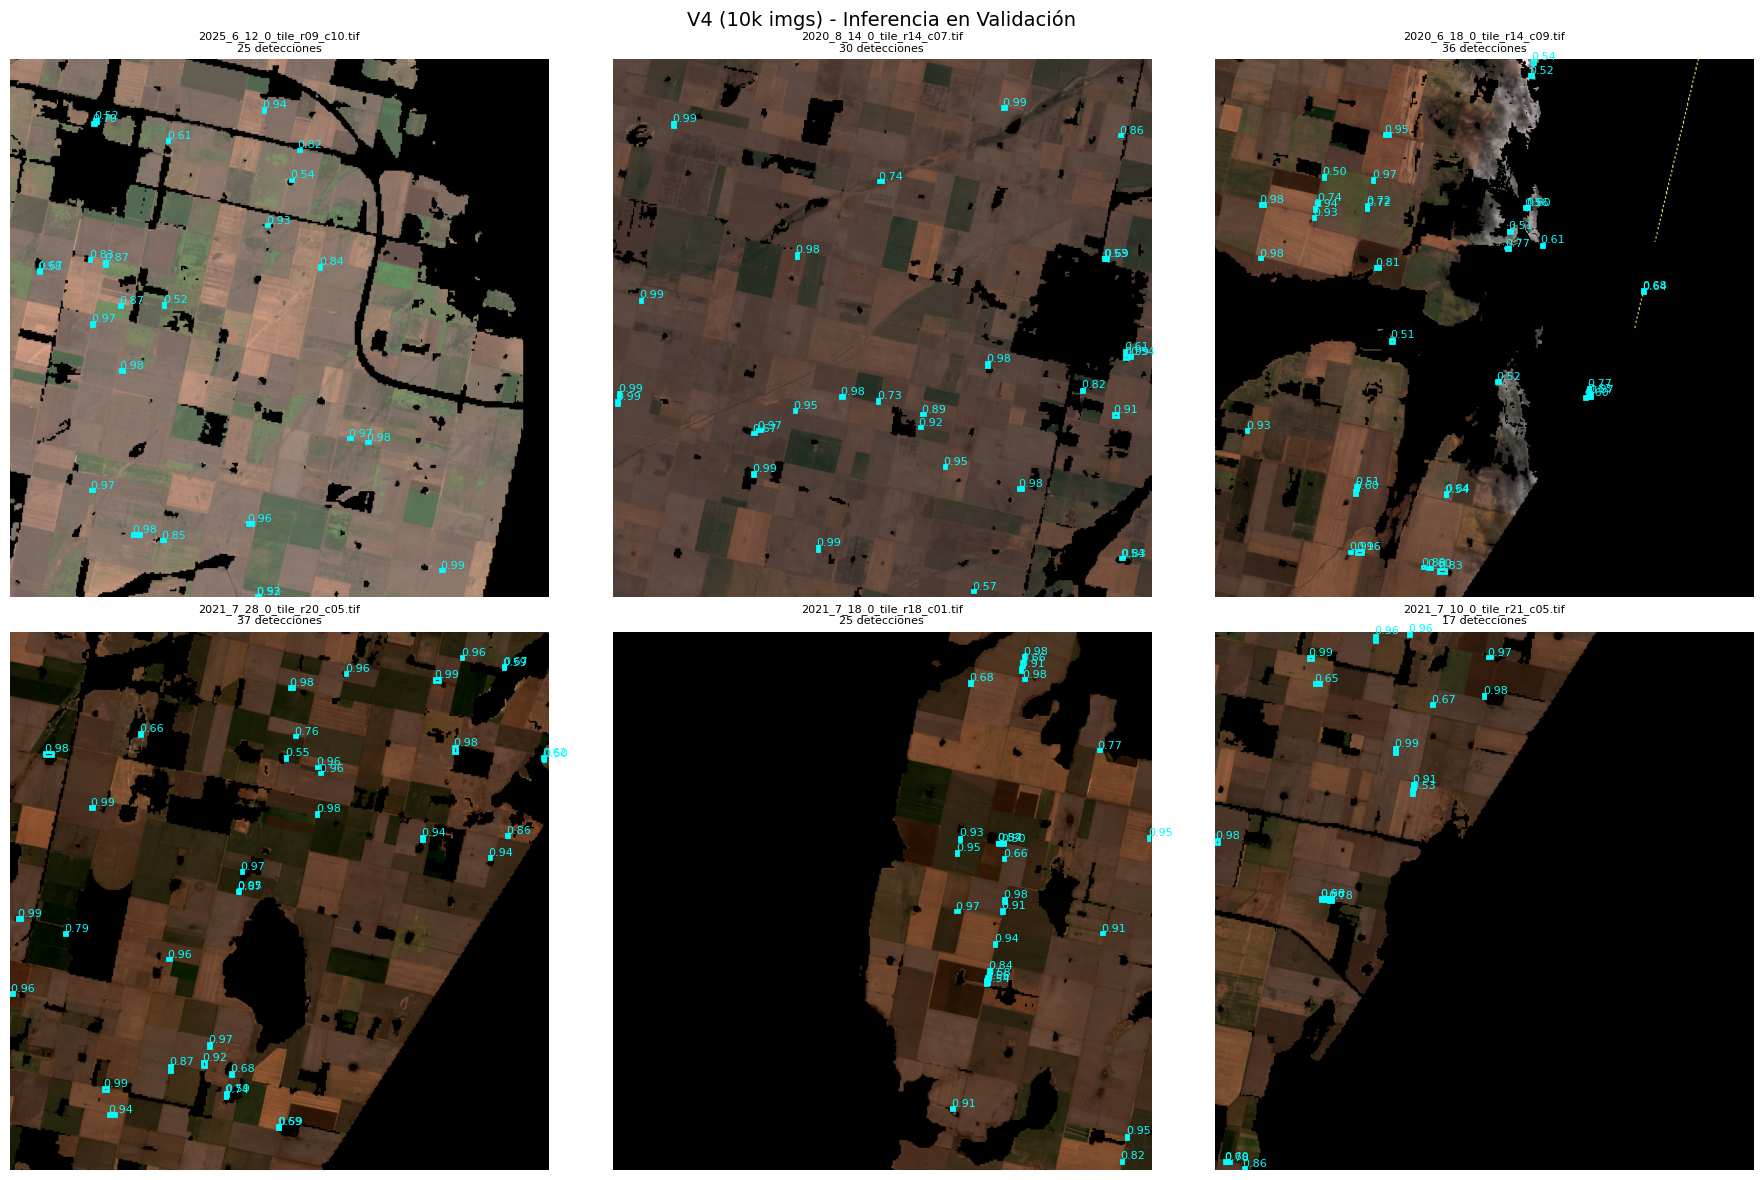

In [3]:
import os
import torch
import torchvision
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import random

MODEL_PATH = r"D:\Silos\modelo_silos_v4_10k.pth"
TEST_IMG_DIR = r"D:\Silos\Dataset_V4_10k\val"
THRESHOLD = 0.5
N_SAMPLES = 6


def get_model_v4(num_classes=2):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None, weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def preprocess(img_path):
    with rasterio.open(img_path) as src:
        try:
            img = src.read([1, 2, 3])
        except:
            img = src.read()[:3]
    img = np.nan_to_num(img.astype(np.float32), nan=0.0)
    if np.max(img) > 255.0:
        img /= 10000.0
    elif np.max(img) > 1.0:
        img /= 255.0
    return torch.as_tensor(np.clip(img, 0, 1), dtype=torch.float32)


# Cargar modelo
device = torch.device('cpu')
model = get_model_v4()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# Seleccionar imágenes random
val_imgs = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.tif')]
random.seed(42)
samples = random.sample(val_imgs, min(N_SAMPLES, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_name in enumerate(samples):
    img_path = os.path.join(TEST_IMG_DIR, img_name)
    img_tensor = preprocess(img_path)
    
    with torch.no_grad():
        pred = model([img_tensor.to(device)])
    
    # Mostrar imagen
    img_np = img_tensor.numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * 2.5, 0, 1)  # Realzar contraste para visualización
    axes[i].imshow(img_np)
    
    # Dibujar boxes
    boxes = pred[0]['boxes'].cpu().numpy()
    scores = pred[0]['scores'].cpu().numpy()
    n_det = 0
    for b, s in zip(boxes, scores):
        if s >= THRESHOLD:
            x1, y1, x2, y2 = b
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor='cyan', facecolor='none'
            )
            axes[i].add_patch(rect)
            axes[i].text(x1, y1 - 2, f'{s:.2f}', color='cyan', fontsize=8)
            n_det += 1
    
    axes[i].set_title(f'{img_name}\n{n_det} detecciones', fontsize=8)
    axes[i].axis('off')

plt.suptitle('V4 (10k imgs) - Inferencia en Validación', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Exportar predicciones de la celda de inferencia a archivos geoespaciales
# Guarda por imagen y un archivo combinado en DATASET_DIR/pred
from pathlib import Path
from shapely.geometry import Polygon
import geopandas as gpd
import rasterio
import torch
import os
import numpy as np

pred_dir = Path(DATASET_DIR) / "pred"
pred_dir.mkdir(parents=True, exist_ok=True)

all_records = []

# Usar la misma selección aleatoria que en la celda de inferencia
val_imgs = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.tif')]
random.seed(42)
samples = random.sample(val_imgs, min(N_SAMPLES, len(val_imgs)))

for img_name in samples:
    img_path = os.path.join(TEST_IMG_DIR, img_name)
    with rasterio.open(img_path) as src:
        transform = src.transform
        crs = src.crs

    # Preprocesar (misma lógica que la celda de inferencia)
    img_tensor = preprocess(img_path)

    with torch.no_grad():
        pred = model([img_tensor.to(device)])

    boxes = pred[0]['boxes'].cpu().numpy()
    scores = pred[0]['scores'].cpu().numpy()

    # Filtrar por umbral
    sel_idxs = np.where(scores >= THRESHOLD)[0]
    if len(sel_idxs) == 0:
        # crear archivo vacío (GeoJSON) para trazabilidad
        empty_gdf = gpd.GeoDataFrame(columns=['image','score'], geometry=[], crs=crs)
        empty_gdf.to_file(pred_dir / f"{img_name}_pred.geojson", driver='GeoJSON')
        continue

    records = []
    for idx in sel_idxs:
        x1, y1, x2, y2 = boxes[idx]
        score = float(scores[idx])

        # Crear polygon en coordenadas pixel -> transformar a coordenadas geográficas
        # esquinas en pixel: (x1,y1) top-left, (x2,y1), (x2,y2), (x1,y2)
        corners_px = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
        corners_geo = []
        for x_px, y_px in corners_px:
            # rasterio.transform.xy usa (row, col) == (y, x)
            lon, lat = rasterio.transform.xy(transform, int(round(y_px)), int(round(x_px)))
            corners_geo.append((lon, lat))

        poly = Polygon(corners_geo)
        records.append({'image': img_name, 'score': score, 'geometry': poly})
        all_records.append({'image': img_name, 'score': score, 'geometry': poly})

    gdf = gpd.GeoDataFrame(records, geometry='geometry', crs=crs)
    # Guardar por imagen (GeoJSON y Shapefile)
    out_geo = pred_dir / f"{img_name}_pred.geojson"
    out_shp_dir = pred_dir / f"{img_name}_pred_shp"
    gdf.to_file(out_geo, driver='GeoJSON')
    # Escribimos shapefile en una carpeta por imagen para evitar problemas de nombres
    out_shp = pred_dir / f"{img_name}_pred.shp"
    try:
        gdf.to_file(out_shp)
    except Exception:
        # fallback: escribir en carpeta
        out_shp_dir.mkdir(exist_ok=True)
        gdf.to_file(out_shp_dir / f"{img_name}_pred.shp")

# Guardar combinado
if len(all_records) > 0:
    combined_gdf = gpd.GeoDataFrame(all_records, geometry='geometry', crs=crs)
    combined_gdf.to_file(pred_dir / "combined_predictions.geojson", driver='GeoJSON')
    combined_gdf.to_file(pred_dir / "combined_predictions.shp")

print(f"Predicciones exportadas en: {pred_dir}")


Predicciones exportadas en: D:\Silos\Dataset_V4_10k\pred
